In [8]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
df = pd.read_csv("TestAnomalyUnlabled.csv")
df.info()
df= df.dropna()
anomaly_inputs = ['temperature_c','humidity_pct','pressure_hpa']
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(df[anomaly_inputs])
df['anomaly_scores'] = model.decision_function(df[anomaly_inputs])
df['anomaly'] = model.predict(df[anomaly_inputs])
df.loc[:,['timestamp','temperature_c','humidity_pct','pressure_hpa','anomaly_scores','anomaly']]


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      1000 non-null   str    
 1   temperature_c  1000 non-null   float64
 2   humidity_pct   1000 non-null   float64
 3   pressure_hpa   1000 non-null   float64
dtypes: float64(3), str(1)
memory usage: 31.4 KB


,timestamp,temperature_c,humidity_pct,pressure_hpa,anomaly_scores,anomaly
0,2026-08-01 08:00:00,29.054849,67.952574,1007.841817,0.028247,1
1,2026-08-01 08:01:00,28.852943,67.316221,1007.782302,0.019378,1
2,2026-08-01 08:02:00,29.215345,67.467761,1008.182620,0.029692,1
3,2026-08-01 08:03:00,29.289658,68.206237,1008.134222,0.020688,1
4,2026-08-01 08:04:00,28.809215,67.601390,1007.569751,0.015327,1
...,...,...,...,...,...,...
995,2026-08-02 00:35:00,31.184471,63.011156,1009.086194,0.089758,1
996,2026-08-02 00:36:00,31.257329,62.944818,1008.943007,0.082095,1
997,2026-08-02 00:37:00,31.138877,62.634105,1010.194387,0.078969,1
998,2026-08-02 00:38:00,31.137804,62.289677,1009.677271,0.086645,1


In [15]:
def outlier_plot(data,outlier_method_name,x_var,y_var,xaxis_limits =[0,1],yaxis_limits=[0,1]):
    print("Outlier Method: ",outlier_method_name)
    print(f'{outlier_method_name}_anomaly')
    print(f"No. of anomalous values: {len(data[data['anomaly']==-1])}")
    print(f"no.of non-anomalous values: {len(data[data['anomaly']==1])}")
    print(f"total number of values: {len(data)}")
    g = sns.FacetGrid(data,col='anomaly',height=4,hue='anomaly', hue_order=[1,-1])
    g.map(sns.scatterplot, x_var, y_var)
    g.fig.suptitle(f"outlier method: {outlier_method_name}", y=1.10, fontweight = 'bold')
    g.set(xlim=xaxis_limits, ylim=yaxis_limits)
    axes = g.axes.flatten()
    axes[0].set_title(f"Outliers: {len(data[data['anomaly']==-1])}points")
    axes[1].set_title(f"Non-Outliers: {len(data[data['anomaly']==1])}points")
    return g
    

Outlier Method:  Isolation Forest
Isolation Forest_anomaly
No. of anomalous values: 100
no.of non-anomalous values: 900
total number of values: 1000


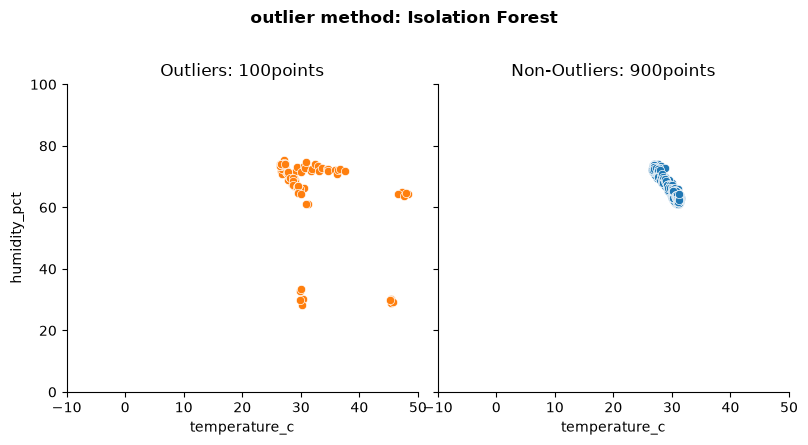

In [16]:
outlier_plot(df,"Isolation Forest","temperature_c","humidity_pct",[-10,50],[0,100])


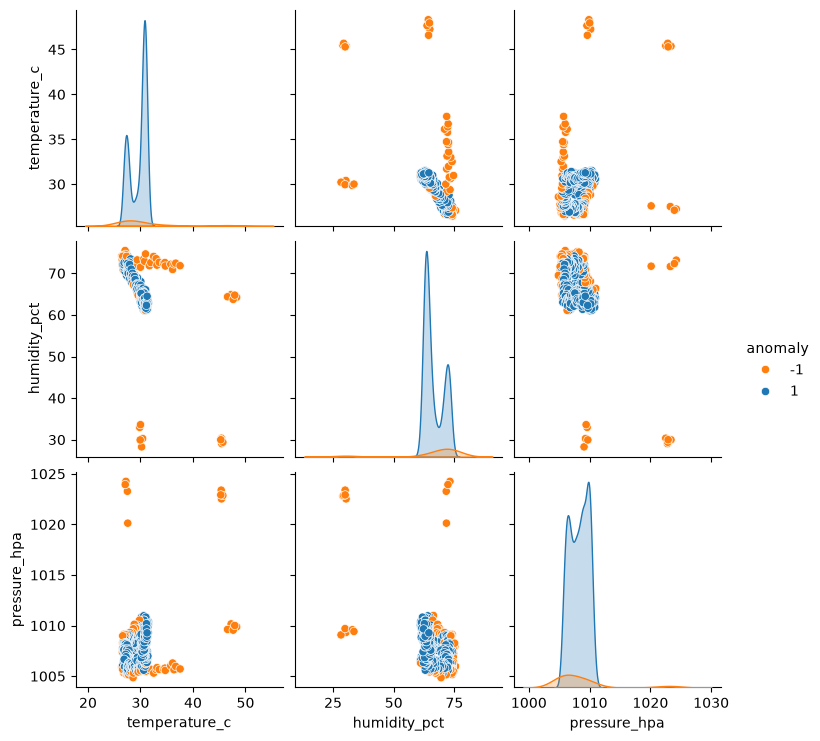

In [18]:
palette = ['#ff7f0e','#1f77b4']
sns.pairplot(df, vars = anomaly_inputs, hue = 'anomaly', palette = palette)